# Exploratory Data Analysis (EDA)

## Overview

This notebook performs a exploratory data analysis of the [Bank Marketing dataset](https://archive.ics.uci.edu/dataset/222/bank+marketing), which contains information on direct marketing campaigns conducted via phone calls. Each record represents a single contact with a client, meaning the same individual may appear multiple times across different campaigns.

The objective of this analysis is to understand the structure, quality, and underlying patterns of the dataset before moving on to preprocessing and modeling.

## Objectives

* Inspect the dataset structure, feature types, and overall quality
* Identify explicit and implicit missing values (e.g., `"unknown"` categories and sentinel values like `pdays = -1`)
* Analyze the distribution of numerical features and detect outliers
* Evaluate categorical variables and their relationship with the target variable
* Assess class imbalance in the target (`y`)
* Identify potential data leakage (e.g., `duration`)
* Derive insights to guide preprocessing and feature engineering decisions

## Dataset Description

The dataset consists of **45,211 observations** and **17 features**, including both numerical and categorical variables related to client demographics, financial status, and previous marketing interactions.

The target variable (`y`) indicates whether the client subscribed to a term deposit (`yes` / `no`).

## Key Considerations

* Missing data is not explicitly encoded as nulls but appears as `"unknown"` or special values
* The dataset is **imbalanced**, with a significantly higher proportion of non-subscriptions
* Some features (such as `duration`) may introduce **data leakage** if used improperly
* Several numerical variables exhibit **skewness and outliers**, motivating transformations or binning

## Outcome

The insights gained from this analysis will directly inform the preprocessing pipeline and feature engineering steps in the next notebook, ensuring that the data is transformed in a way that is both robust and aligned with the modeling objective.


In [1]:
# quarto preview 01_eda.ipynb --to pdf
# quarto render 01_eda.ipynb
# black 01_eda.ipynb

## Exploratory Data Analysis

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
EDA_COLOR = "#2E5AAC"  # single accent for all EDA plots (bars, counts, hists)
pd.set_option("display.max_columns", 25)

DATA_PATH = Path("data/bank-full.csv")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

### 1. Load raw data

In [3]:
assert DATA_PATH.exists(), f"Missing file: {DATA_PATH.resolve()}"

df = pd.read_csv(DATA_PATH, sep=";")
print("Shape:", df.shape)
df.head()

Shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


**Interpretation:** The raw dataset has 45,211 rows and 17 columns. Each row represents a single phone-call contact attempt — one client may appear more than once if contacted in multiple campaigns. The semicolon-delimited format is the standard export for the UCI Bank Marketing dataset.

### 2. Schema, types, and missing values

In [4]:
display(df.info())

na_counts = df.isna().sum()
na_counts[na_counts > 0]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


None

Series([], dtype: int64)

**Interpretation:** No explicit null values exist in the raw file — missingness is encoded indirectly as the string `"unknown"` in categorical columns and as `-1` in `pdays`. Numeric columns (age, balance, duration, campaign, pdays, previous) span a wide range; `pdays = -1` is a sentinel meaning the client was never previously contacted.

In [5]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in df.columns if c not in numeric_cols and c != "y"]

print("Numeric:", numeric_cols)
print("Categorical:", categorical_cols)

df.describe().T

Numeric: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Categorical: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.936210,10.618762,18.0,33.0,39.0,48.0,95.0
balance,45211.0,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
day,45211.0,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0
duration,45211.0,258.163080,257.527812,0.0,103.0,180.0,319.0,4918.0
campaign,45211.0,2.763841,3.098021,1.0,1.0,2.0,3.0,63.0
pdays,45211.0,40.197828,100.128746,-1.0,-1.0,-1.0,-1.0,871.0
previous,45211.0,0.580323,2.303441,0.0,0.0,0.0,0.0,275.0


**Interpretation:** The wide variance in `balance` (including negative values from overdraft accounts) and the heavy right-skew in `duration` and `campaign` confirm that these columns need bucketing or transformation before use in linear models. Note that `duration` is only known after the call ends — it can be a leakage risk for realistic pre-call prediction scenarios.

### 3. Sentinel values and implicit missingness

In this dataset, `pdays == -1` means the client was not contacted in the previous campaign (not a real day count). We record that explicitly below.

In [6]:
unknown_like = df[categorical_cols].eq("unknown").sum().sort_values(ascending=False)
unknown_like[unknown_like > 0]

poutcome     36959
contact      13020
education     1857
job            288
dtype: int64

**Interpretation:** The counts above rank how often `"unknown"` appears in each categorical column; the largest values are in `poutcome` and `contact`, so previous campaign outcome and contact method are missing for many rows. Rather than dropping these rows, `"unknown"` is treated as a valid category — it may itself carry signal, as clients with unknown contact or outcome history may behave differently.

### 4. Duplicates and consistency

In [7]:
dup_mask = df.duplicated()
n_dup = dup_mask.sum()
print(f"Duplicate rows (all columns): {n_dup}")

key_cols = [
    c for c in df.columns if c not in {"duration", "campaign"}
]  # exclude call outcomes if modeling leakage
dup_key = df.duplicated(subset=key_cols)
print(f"Duplicates on subset (excluding duration, campaign): {dup_key.sum()}")

df_clean = df.loc[~dup_mask].copy()
print("After dropping exact duplicates:", df_clean.shape)

Duplicate rows (all columns): 0
Duplicates on subset (excluding duration, campaign): 53
After dropping exact duplicates: (45211, 17)


**Interpretation:** No fully identical rows were found, so the dataset remains at 45,211 records after duplicate checks. A small number of rows share identical pre-call attributes when excluding outcome-related variables (`duration`, `campaign`), but these do not represent true duplicates. Instead, they likely correspond to separate contact attempts that happen to have the same recorded characteristics. Since each row represents a distinct interaction, these repeated observations are valid and are retained. Only exact, all-column duplicates would have been removed but there weren't any.

### 5. Target variable and class balance

y
no     0.883015
yes    0.116985
Name: proportion, dtype: float64

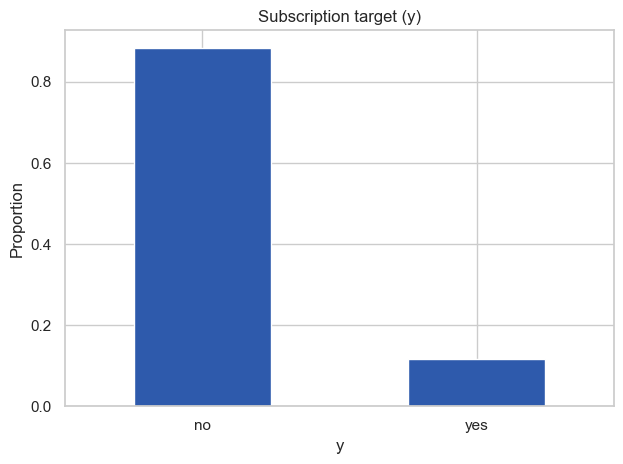

In [8]:
target = "y"
vc = df_clean[target].value_counts(normalize=True)
display(vc)
vc.plot(kind="bar", title="Subscription target (y)", rot=0, color=EDA_COLOR)
plt.ylabel("Proportion")
plt.tight_layout()
plt.show()

**Interpretation:** The target is heavily imbalanced: the printed normalized frequencies and bar heights use proportions on [0, 1] — `no` is near 0.88 and `yes` near 0.12. A naive classifier that always predicts `no` would achieve accuracy near that majority proportion (~0.88), so accuracy alone is a misleading metric. Stratified train/validation/test splits are used throughout to preserve class proportions across all sets.

### 6. Outliers and distributions (numeric)

balance: IQR outliers = 4729 (bounds [-1962.00, 3462.00])
duration: IQR outliers = 3235 (bounds [-221.00, 643.00])
campaign: IQR outliers = 3064 (bounds [-2.00, 6.00])
age: IQR outliers = 487 (bounds [10.50, 70.50])


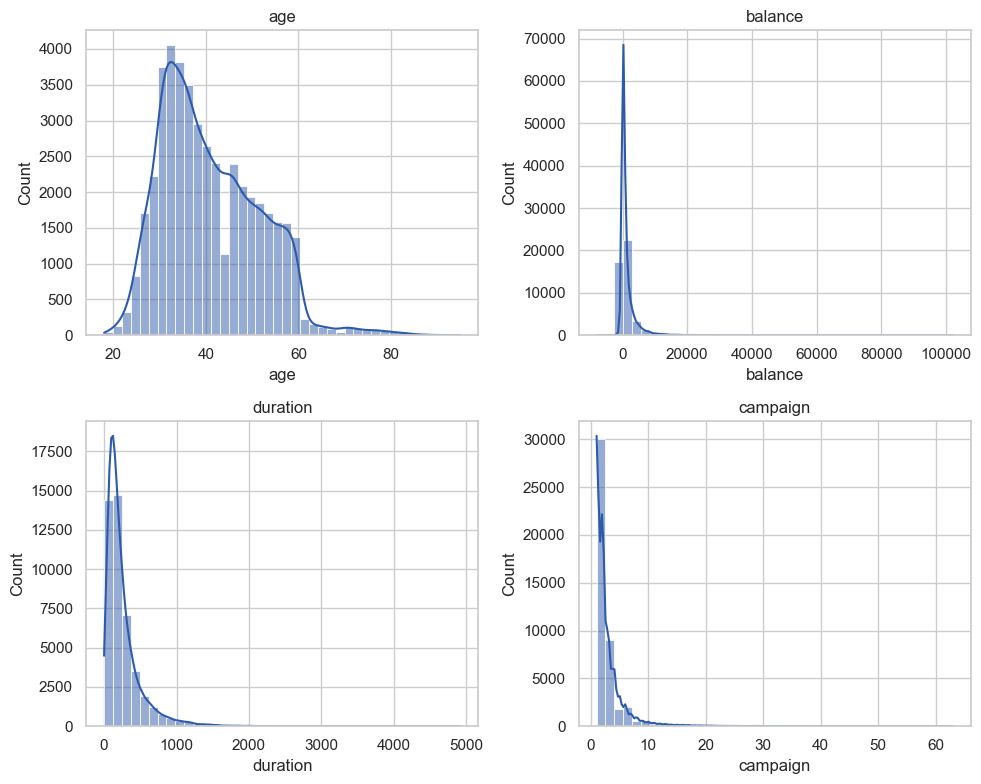

In [9]:
def iqr_bounds(s: pd.Series, k: float = 1.5) -> tuple[float, float]:
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr


for col in ["balance", "duration", "campaign", "age"]:
    lo, hi = iqr_bounds(df_clean[col])
    out = ((df_clean[col] < lo) | (df_clean[col] > hi)).sum()
    print(f"{col}: IQR outliers = {out} (bounds [{lo:.2f}, {hi:.2f}])")

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, col in zip(axes.ravel(), ["age", "balance", "duration", "campaign"]):
    sns.histplot(df_clean[col], bins=40, kde=True, color=EDA_COLOR, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

**Interpretation:** `balance`, `duration`, and `campaign` each have many IQR outliers driven by a long right tail. `balance` can be negative (overdraft accounts are valid). These distributions motivate bucketing (used in Section 2.4) rather than raw numeric input for robust modeling. `duration` is excluded from the final feature set as it is known only after the call concludes, making it a leakage source for pre-call targeting.

### 7. Target-wise EDA for categorical variables

### 7.1. job

,category,count,proportion,subscription_rate
0,blue-collar,9732,0.215257,0.072750
1,management,9458,0.209197,0.137556
2,technician,7597,0.168034,0.110570
3,admin.,5171,0.114375,0.122027
4,services,4154,0.091880,0.088830
5,retired,2264,0.050076,0.227915
6,self-employed,1579,0.034925,0.118429
7,entrepreneur,1487,0.032890,0.082717
8,unemployed,1303,0.028820,0.155027
9,housemaid,1240,0.027427,0.087903


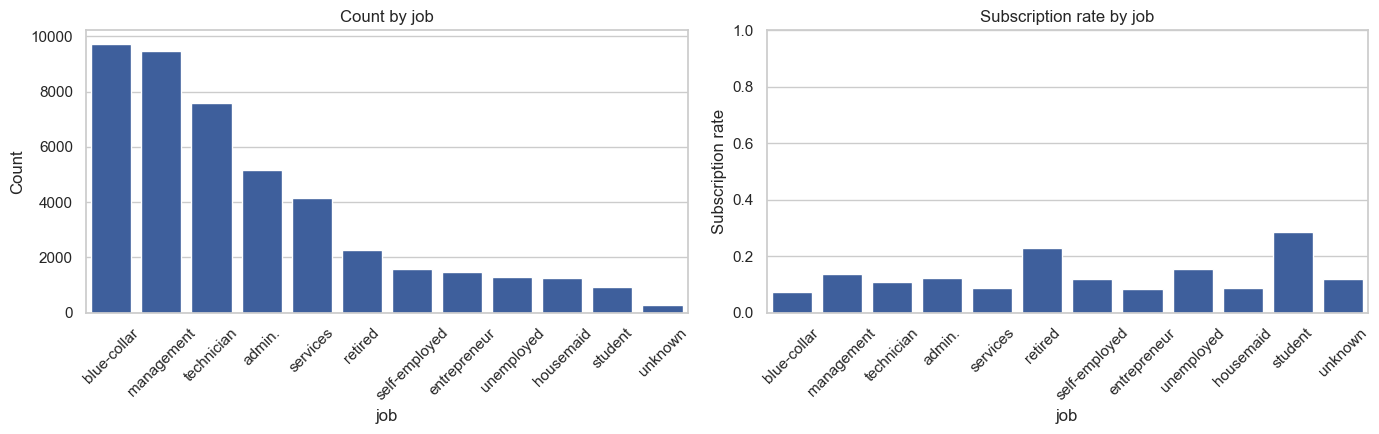

In [10]:
col = "job"

summary = (
    df_clean.groupby(col, dropna=False)
    .agg(count=("y", "size"))
    .reset_index()
    .rename(columns={col: "category"})
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

subscription_rate = (
    df_clean.groupby(col, dropna=False)["y"]
    .apply(lambda s: (s == "yes").mean())
    .reset_index(name="subscription_rate")
    .rename(columns={col: "category"})
)

summary = summary.merge(subscription_rate, on="category", how="left")
summary["proportion"] = summary["count"] / len(df_clean)
summary = summary[["category", "count", "proportion", "subscription_rate"]]

display(summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.countplot(data=df_clean, x=col, order=summary["category"], color=EDA_COLOR, ax=axes[0])
axes[0].set_title(f"Count by {col}")
axes[0].set_xlabel(col)
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(data=summary, x="category", y="subscription_rate", color=EDA_COLOR, ax=axes[1])
axes[1].set_title(f"Subscription rate by {col}")
axes[1].set_xlabel(col)
axes[1].set_ylabel("Subscription rate")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

**Interpretation:** Blue-collar workers are the most common job category, but `retired` and `student` clients subscribe at noticeably higher rates than average. This suggests that economic activity and time availability may influence deposit adoption. Job type is a useful feature for targeting high-value segments.

### 7.2. marital

,category,count,proportion,subscription_rate
0,married,27214,0.601933,0.101235
1,single,12790,0.282896,0.149492
2,divorced,5207,0.115171,0.119455


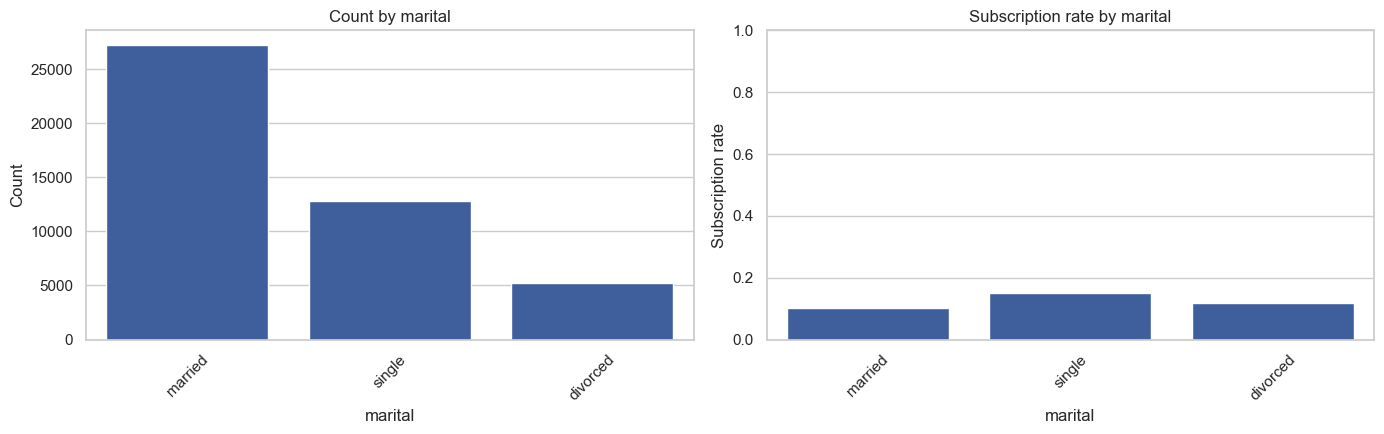

In [11]:
col = "marital"

summary = (
    df_clean.groupby(col, dropna=False)
    .agg(count=("y", "size"))
    .reset_index()
    .rename(columns={col: "category"})
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

subscription_rate = (
    df_clean.groupby(col, dropna=False)["y"]
    .apply(lambda s: (s == "yes").mean())
    .reset_index(name="subscription_rate")
    .rename(columns={col: "category"})
)

summary = summary.merge(subscription_rate, on="category", how="left")
summary["proportion"] = summary["count"] / len(df_clean)
summary = summary[["category", "count", "proportion", "subscription_rate"]]

display(summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.countplot(data=df_clean, x=col, order=summary["category"], color=EDA_COLOR, ax=axes[0])
axes[0].set_title(f"Count by {col}")
axes[0].set_xlabel(col)
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(data=summary, x="category", y="subscription_rate", color=EDA_COLOR, ax=axes[1])
axes[1].set_title(f"Subscription rate by {col}")
axes[1].set_xlabel(col)
axes[1].set_ylabel("Subscription rate")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

**Interpretation:** Married clients are the most common group (tallest bar on the count plot), but single clients have a slightly higher subscription rate in the right-hand panel (heights are `P(y=yes)` on [0, 1]). The gap between married and single is modest (~0.03–0.04), but marital status still provides a simple split and will be retained as a categorical feature for one-hot encoding.

### 7.3. education

,category,count,proportion,subscription_rate
0,secondary,23202,0.513194,0.105594
1,tertiary,13301,0.294198,0.150064
2,primary,6851,0.151534,0.086265
3,unknown,1857,0.041074,0.135703


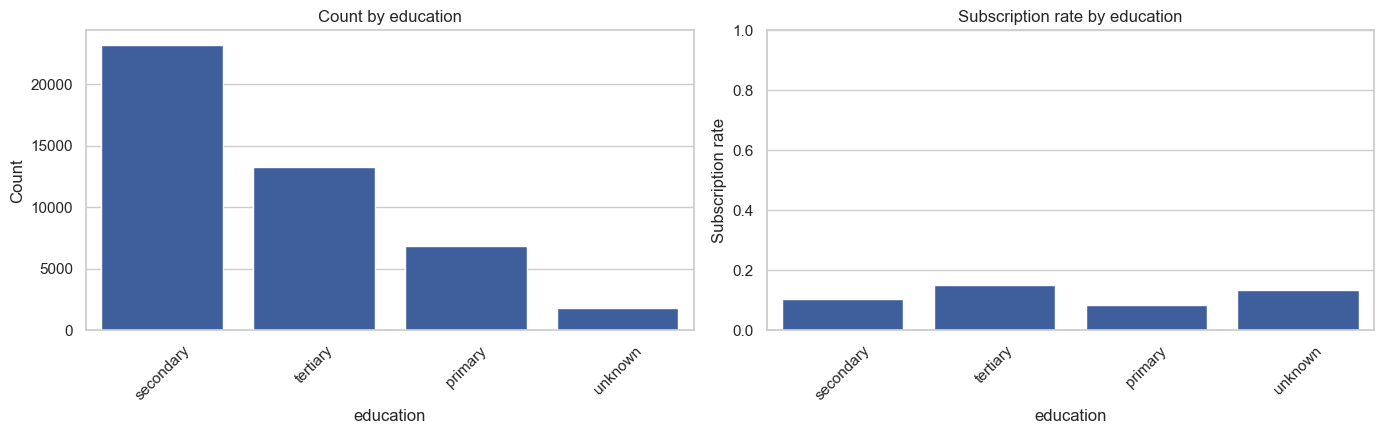

In [12]:
col = "education"

summary = (
    df_clean.groupby(col, dropna=False)
    .agg(count=("y", "size"))
    .reset_index()
    .rename(columns={col: "category"})
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

subscription_rate = (
    df_clean.groupby(col, dropna=False)["y"]
    .apply(lambda s: (s == "yes").mean())
    .reset_index(name="subscription_rate")
    .rename(columns={col: "category"})
)

summary = summary.merge(subscription_rate, on="category", how="left")
summary["proportion"] = summary["count"] / len(df_clean)
summary = summary[["category", "count", "proportion", "subscription_rate"]]

display(summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.countplot(data=df_clean, x=col, order=summary["category"], color=EDA_COLOR, ax=axes[0])
axes[0].set_title(f"Count by {col}")
axes[0].set_xlabel(col)
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(data=summary, x="category", y="subscription_rate", color=EDA_COLOR, ax=axes[1])
axes[1].set_title(f"Subscription rate by {col}")
axes[1].set_xlabel(col)
axes[1].set_ylabel("Subscription rate")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

**Interpretation:** Tertiary-educated clients subscribe at a clearly higher rate than secondary or primary on the right-hand panel. The `unknown` group's subscription rate sits between primary and secondary (closer to secondary), well below tertiary — so it should not be read as a high-education proxy. In preprocessing we keep `education` as a categorical field (including `unknown` as its own level) and encode it with one-hot features rather than forcing a single ordinal score.

### 7.4. housing

,category,count,proportion,subscription_rate
0,yes,25130,0.555838,0.077000
1,no,20081,0.444162,0.167024


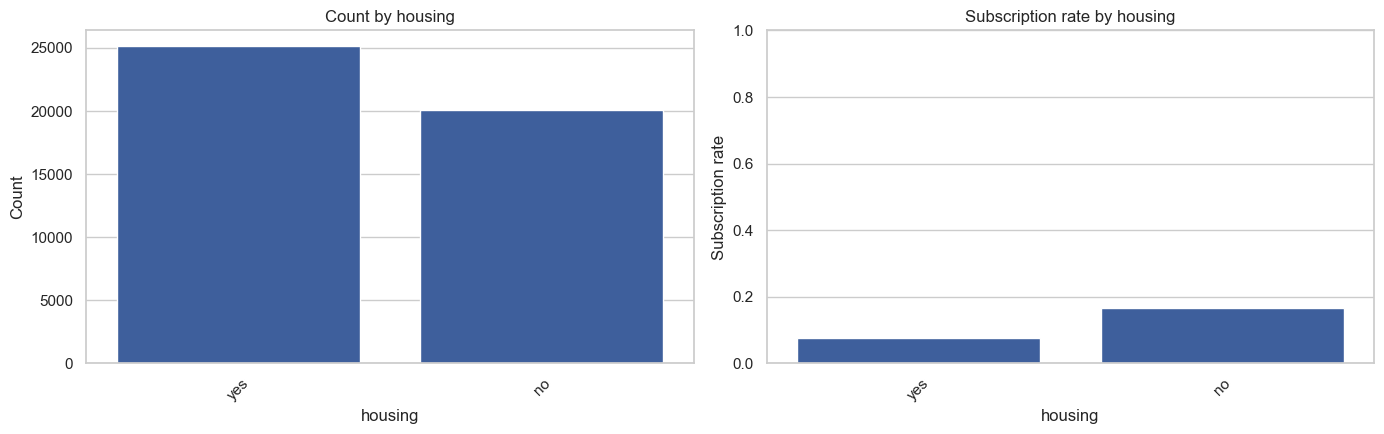

In [13]:
col = "housing"

summary = (
    df_clean.groupby(col, dropna=False)
    .agg(count=("y", "size"))
    .reset_index()
    .rename(columns={col: "category"})
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

subscription_rate = (
    df_clean.groupby(col, dropna=False)["y"]
    .apply(lambda s: (s == "yes").mean())
    .reset_index(name="subscription_rate")
    .rename(columns={col: "category"})
)

summary = summary.merge(subscription_rate, on="category", how="left")
summary["proportion"] = summary["count"] / len(df_clean)
summary = summary[["category", "count", "proportion", "subscription_rate"]]

display(summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.countplot(
    data=df_clean,
    x=col,
    order=summary["category"],
    color=EDA_COLOR,
    ax=axes[0],
)
axes[0].set_title(f"Count by {col}")
axes[0].set_xlabel(col)
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(
    data=summary,
    x="category",
    y="subscription_rate",
    order=summary["category"],
    color=EDA_COLOR,
    ax=axes[1],
)
axes[1].set_title(f"Subscription rate by {col}")
axes[1].set_xlabel(col)
axes[1].set_ylabel("Subscription rate")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


**Interpretation:** Clients with a housing loan subscribe at a lower rate than those without one. Having an existing mortgage obligation may reduce financial capacity or willingness to commit to a new term deposit. The `housing_binary` feature captures this signal directly.

### 7.5. loan

,category,count,proportion,subscription_rate
0,yes,7244,0.160226,0.066814
1,no,37967,0.839774,0.126557


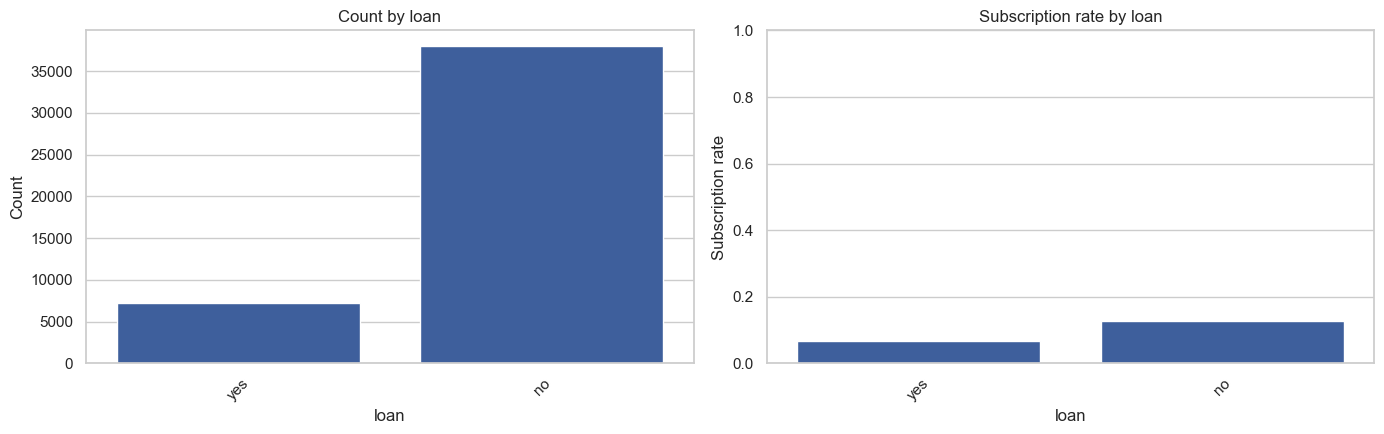

In [14]:
col = "loan"

summary = (
    df_clean.groupby(col, dropna=False)
    .agg(count=("y", "size"))
    .reset_index()
    .rename(columns={col: "category"})
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

subscription_rate = (
    df_clean.groupby(col, dropna=False)["y"]
    .apply(lambda s: (s == "yes").mean())
    .reset_index(name="subscription_rate")
    .rename(columns={col: "category"})
)

summary = summary.merge(subscription_rate, on="category", how="left")
summary["proportion"] = summary["count"] / len(df_clean)
summary = summary[["category", "count", "proportion", "subscription_rate"]]

# Keep 'yes' to the left of 'no' in plots (and display table when both exist).
preferred = ["yes", "no", "Yes", "No"]
category_order = [c for c in preferred if c in summary["category"].values]
category_order += [c for c in summary["category"] if c not in category_order]
summary["category"] = pd.Categorical(
    summary["category"], categories=category_order, ordered=True
)
summary = summary.sort_values("category").reset_index(drop=True)

display(summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.countplot(
    data=df_clean,
    x=col,
    order=category_order,
    color=EDA_COLOR,
    ax=axes[0],
)
axes[0].set_title(f"Count by {col}")
axes[0].set_xlabel(col)
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(
    data=summary,
    x="category",
    y="subscription_rate",
    order=category_order,
    color=EDA_COLOR,
    ax=axes[1],
)
axes[1].set_title(f"Subscription rate by {col}")
axes[1].set_xlabel(col)
axes[1].set_ylabel("Subscription rate")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


**Interpretation:** Personal loan holders subscribe at a lower rate, mirroring the housing loan pattern. The combined presence of both housing and personal loans is captured through the `both_housing_and_personal_loan` interaction feature in Section 2.3, which may identify the highest-debt — and thus least likely to subscribe — client segment.

### 7.6. contact

,category,count,proportion,subscription_rate
0,cellular,29285,0.647741,0.149189
1,unknown,13020,0.287983,0.040707
2,telephone,2906,0.064276,0.134205


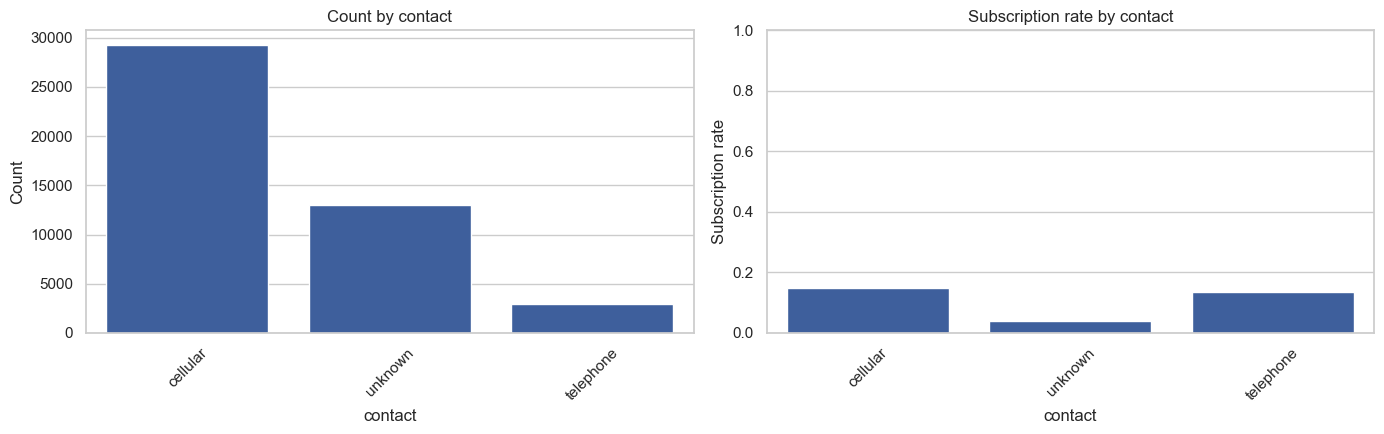

In [15]:
col = "contact"

summary = (
    df_clean.groupby(col, dropna=False)
    .agg(count=("y", "size"))
    .reset_index()
    .rename(columns={col: "category"})
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

subscription_rate = (
    df_clean.groupby(col, dropna=False)["y"]
    .apply(lambda s: (s == "yes").mean())
    .reset_index(name="subscription_rate")
    .rename(columns={col: "category"})
)

summary = summary.merge(subscription_rate, on="category", how="left")
summary["proportion"] = summary["count"] / len(df_clean)
summary = summary[["category", "count", "proportion", "subscription_rate"]]

display(summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.countplot(data=df_clean, x=col, order=summary["category"], color=EDA_COLOR, ax=axes[0])
axes[0].set_title(f"Count by {col}")
axes[0].set_xlabel(col)
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(data=summary, x="category", y="subscription_rate", color=EDA_COLOR, ax=axes[1])
axes[1].set_title(f"Subscription rate by {col}")
axes[1].set_xlabel(col)
axes[1].set_ylabel("Subscription rate")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

**Interpretation:** Cellular contact is associated with higher subscription rates than telephone or unknown contact method. The large `unknown` segment has lower rates, likely reflecting less targeted outreach. The `contact_is_unknown` binary flag in Section 2.2 captures this distinction rather than one-hot encoding all three levels.

### 7.7. month

,category,count,proportion,subscription_rate
0,may,13766,0.304483,0.067195
1,jul,6895,0.152507,0.090935
2,aug,6247,0.138174,0.110133
3,jun,5341,0.118135,0.102228
4,nov,3970,0.087810,0.101511
5,apr,2932,0.064851,0.196794
6,feb,2649,0.058592,0.166478
7,jan,1403,0.031032,0.101212
8,oct,738,0.016323,0.437669
9,sep,579,0.012807,0.464594


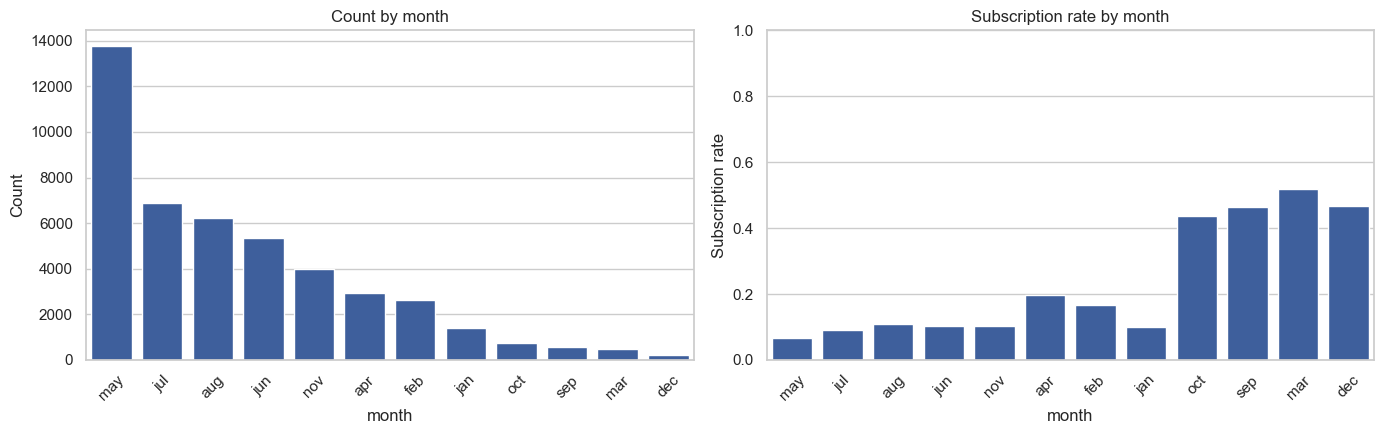

In [16]:
col = "month"

summary = (
    df_clean.groupby(col, dropna=False)
    .agg(count=("y", "size"))
    .reset_index()
    .rename(columns={col: "category"})
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

subscription_rate = (
    df_clean.groupby(col, dropna=False)["y"]
    .apply(lambda s: (s == "yes").mean())
    .reset_index(name="subscription_rate")
    .rename(columns={col: "category"})
)

summary = summary.merge(subscription_rate, on="category", how="left")
summary["proportion"] = summary["count"] / len(df_clean)
summary = summary[["category", "count", "proportion", "subscription_rate"]]

display(summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.countplot(data=df_clean, x=col, order=summary["category"], color=EDA_COLOR, ax=axes[0])
axes[0].set_title(f"Count by {col}")
axes[0].set_xlabel(col)
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(data=summary, x="category", y="subscription_rate", color=EDA_COLOR, ax=axes[1])
axes[1].set_title(f"Subscription rate by {col}")
axes[1].set_xlabel(col)
axes[1].set_ylabel("Subscription rate")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

**Interpretation:** Contact volume peaks in May but subscription rates are highest in March, September, October, and December. This non-linear seasonal pattern means an ordinal month encoding would be misleading. Month is therefore kept as an unordered categorical and one-hot encoded in the sklearn pipeline.

### 7.8. poutcome

,category,count,proportion,subscription_rate
0,unknown,36959,0.817478,0.091615
1,failure,4901,0.108403,0.126097
2,other,1840,0.040698,0.166848
3,success,1511,0.033421,0.647253


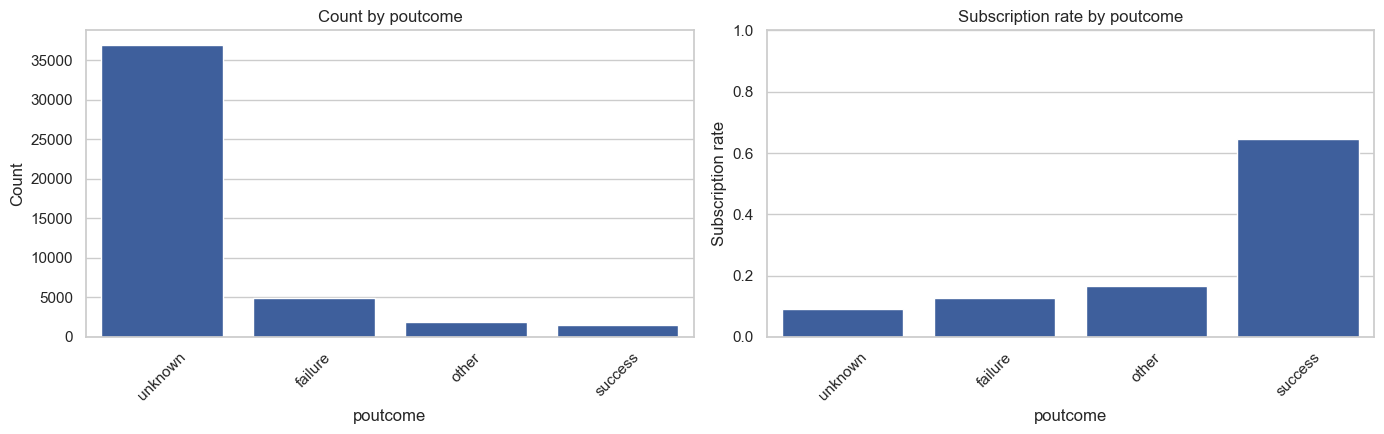

In [17]:
col = "poutcome"
summary = (
    df_clean.groupby(col, dropna=False)
    .agg(count=("y", "size"))
    .reset_index()
    .rename(columns={col: "category"})
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

subscription_rate = (
    df_clean.groupby(col, dropna=False)["y"]
    .apply(lambda s: (s == "yes").mean())
    .reset_index(name="subscription_rate")
    .rename(columns={col: "category"})
)

summary = summary.merge(subscription_rate, on="category", how="left")
summary["proportion"] = summary["count"] / len(df_clean)
summary = summary[["category", "count", "proportion", "subscription_rate"]]

display(summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.countplot(data=df_clean, x=col, order=summary["category"], color=EDA_COLOR, ax=axes[0])
axes[0].set_title(f"Count by {col}")
axes[0].set_xlabel(col)
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(data=summary, x="category", y="subscription_rate", color=EDA_COLOR, ax=axes[1])
axes[1].set_title(f"Subscription rate by {col}")
axes[1].set_xlabel(col)
axes[1].set_ylabel("Subscription rate")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

**Interpretation:** Previous campaign outcome of `"success"` is the strongest single predictor in the EDA — the subscription rate for `"success"` is about 0.65 on the plot, far above the overall baseline near 0.12. `"unknown"` and `"other"` are much weaker on the same scale. This motivates keeping `poutcome_success` as a dedicated binary flag and `poutcome_is_unknown` to distinguish truly missing history from known non-success outcomes.

## Save dataset

After the Exploratory Data Analysis, we need to save the raw data in a parquet file. Since we didn't find any duplicates, we keep all the observations. This file will be the one that we'll use in the following notebook.

In [18]:
print(f"original data: {df.shape}")
print(f"output data: {df_clean.shape}")

original data: (45211, 17)
output data: (45211, 17)


In [19]:
nb = "01"
data_dir = Path("data")
# data_dir.mkdir(parents=True, exist_ok=True)

df_path = data_dir / f"{nb}_raw_data.parquet"

df_clean.to_parquet(df_path, index=False)
print(f"Saved raw data: {df_path}")

Saved raw data: data/01_raw_data.parquet
